# RAG - Retrieval-Augmented Generation

В этом ноутбуке мы:

1. Повторим теорию RAG (что делает ретривер, что делает генератор и зачем они друг другу нужны).

2. В процессе подготовим окружение (установим нужные версии `transformers`, `langchain`, `chromadb`, `bitsandbytes`).Всё тестируем на обычном ноутбуке.

3. Соберём рабочий пайплайн: **DeepSeek-R1-Distill-Llama-8B → LangChain → ChromaDB → RAG‑цепочка**.

4. Натравим RAG на небольшой англоязычный корпус (мини‑выборка из Википедии) и научимся задавать вопросы по‑английски.

5. Оценим качество простейшей метрикой (accuracy@k) и обсудим, куда расти дальше.


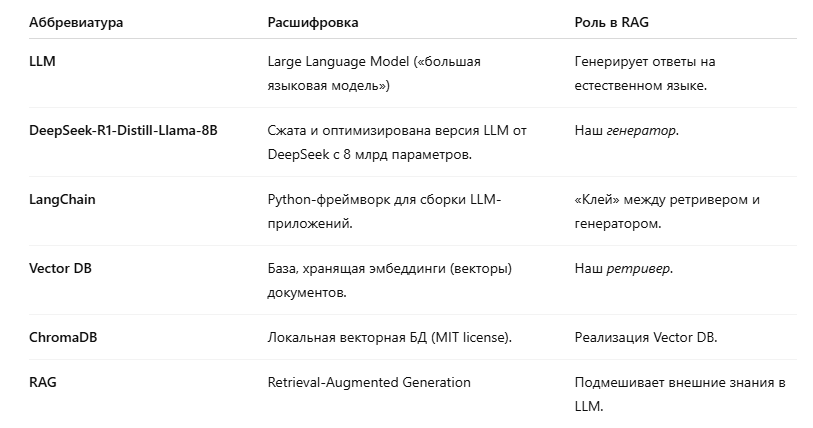

### Что такое Retrieval‑Augmented Generation?

LLM умеют отвечать на вопросы, *если* знали факты при обучении.
Когда вопрос выходит за рамки их памяти, модель начинает галлюцинировать.
**RAG‑архитектура** решает проблему так:

1. **Retriever (извлекатель):**

   * Делает эмбеддинги из текстов (например, с помощью `sentence-transformers`).
   * Индексирует их в векторной базе (`ChromaDB`).
   * По запросу находит самые релевантные отрывки.

2. **Generator (генератор):**

   * Использует LLM (в нашем случае — DeepSeek) для генерации ответа.
   * На вход подаются запрос + найденные документы.

3. **Langchain orchestration:**

   * Автоматизирует связку извлекателя и генератора

Таким образом мы можем
*а)* держать данные локально,
*б)* обновлять знания без дообучения модели.


### BitsAndBytesConfig

**Что вообще по железу в колабе?**

GPU

| Название | Архитектура  | VRAM (примерно) | Особенности                       |
| -------- | ------------ | --------------- | --------------------------------- |
| **A100** | Ampere       | 40–80 GB        | Самый мощный, обычно в Colab Pro+ |
| **L4**   | Ada Lovelace | 24 GB           | Новый, ускоренный inference       |
| **T4**   | Turing       | 16 GB           | Часто доступен в бесплатном Colab |

TPU

| TPU       | Версия | Количество ядер | Примечание                        |
| --------- | ------ | --------------- | --------------------------------- |
| TPU v2-8  | v2     | 8               | Старый, но всё ещё рабочий        |
| TPU v5e-1 | v5e    | 1               | Новый экономичный вариант         |
| TPU v6e-1 | v6e    | 1               | Один из новейших TPU, часто в Pro |

TPU (Tensor Processing Unit) — это специализированный чип (процессор), разработанный компанией Google для ускорения вычислений в задачах машинного обучения, особенно — для тензорных операций, характерных для нейросетей. Грубо говоря, ML-ускоритель - канает для TensorFlow и JAX.

In [ ]:
!nvidia-smi

Fri Mar  6 08:49:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             29W /   70W |    5689MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Тогда вопрос, а если моделька слишком большая или мы сильно ограничены в ресурсах? Используем `BitsAndBytesConfig`!

Когда пойдет его использовать?

* Хочешь запустить **большую LLM на ограниченном железе** (например, RTX 3060 с 6–8 GB VRAM).
* Выполняешь **инференс** (а не обучение).
* Используешь **RAG, chat-ботов или QA-сценарии**, где важна скорость и "достаточная" точность.

`BitsAndBytesConfig` — это специальный класс из библиотеки `transformers`от Hugging Face, который используется для настройки квантования модели при загрузке, особенно в связке с библиотекой `bitsandbytes`. Он позволяет уменьшить объём памяти, занимаемый моделью, за счёт представления весов не в стандартном 16- или 32-битном формате, а в 4- или 8-битном формате.

| Параметр                                | Описание                                                                                                                                |
| --------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| `load_in_4bit=True`                     | Загружаем веса модели в 4-битном формате (сильно уменьшает потребление памяти).                                                         |
| `bnb_4bit_quant_type="nf4"`             | Тип квантования. `nf4` — лучше сохраняет точность (рекомендуется).                                                                      |
| `bnb_4bit_use_double_quant=True`        | Включает двойное квантование — дополнительно уменьшает размер модели за счёт квантования параметров квантования (мета-квантование). |
| `bnb_4bit_compute_dtype=torch.bfloat16` | Указывает, в каком типе данных (dtype) производить вычисления. `bfloat16` быстрее и точнее, чем float16 на большинстве GPU.             |

### import




In [ ]:
!pip install transformers==4.48.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 119.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install -U langchain-core langchain-community langchain-text-splitters langchain-huggingface huggingface_hub chromadb bitsandbytes==0.48.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.7/502.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/23

In [ ]:
from torch import cuda, bfloat16
import torch, transformers
import torchvision
from transformers import AutoTokenizer, BitsAndBytesConfig, pipeline

torchvision.disable_beta_transforms_warning()
DEVICE = f"cuda:{cuda.current_device()}" if cuda.is_available() else "cpu"

In [ ]:
import sys
print(transformers.__version__, sys.executable)

4.48.3 /usr/bin/python3


In [ ]:
import bitsandbytes as bnb, importlib, os

print(bnb.__version__)
!ldconfig -p | grep cusparse | head -n 3

0.48.2
	libcusparse.so.12 (libc6,x86-64) => /usr/local/cuda/targets/x86_64-linux/lib/libcusparse.so.12
	libcusparse.so (libc6,x86-64) => /usr/local/cuda/targets/x86_64-linux/lib/libcusparse.so


### LLM

In [ ]:
from transformers import BitsAndBytesConfig
import torch


MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
# MODEL_ID = 'openchat/openchat-3.5-0106'

# Квантуем в 4 бита, чтобы поместилось в VRAM 6–8 ГБ
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                          # включить 4-битное квантование
    bnb_4bit_quant_type="nf4",                  # тип квантования: "nf4" (Normalized Float 4) или "fp4"
    bnb_4bit_use_double_quant=True,             # включить двойное квантование (дополнительная компрессия)
    bnb_4bit_compute_dtype=torch.float16        # тип данных для вычислений (например, bfloat16 (недоступен на T4), float16)
)

print("Загружаем модель …")
model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    # trust_remote_code=True,
)

# model = transformers.AutoModelForCausalLM.from_pretrained(
#     MODEL_ID,
#     device_map='auto',
#     torch_dtype=torch.float16,
#     low_cpu_mem_usage=True,
#     offload_state_dict=True,
# )

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16, # на всякий случай лучше передать
    device_map="auto",
)

Загружаем модель …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-000002.safetensors:   0%|          | 0.00/8.67G [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Мини-инференс

In [ ]:
def ask_DeepSeek(prompt: str):
    resp = llm_pipeline(
        prompt,
        max_length=200,
        do_sample=True,
        truncation=True,
        top_k=20, # настройка сэмплирования
        num_return_sequences=1,
        eos_token_id=tokenizer.eos_token_id,
    )[0]["generated_text"]
    print(resp)

ask_DeepSeek("Объясни, пожалуйста, что такое ‘State of the Union’. Ответь одним абзацем. Ответь на английском.")

Объясни, пожалуйста, что такое ‘State of the Union’. Ответь одним абзацем. Ответь на английском. 

Okay, so I need to explain what 'State of the Union' means. Hmm, I think it's a speech, right? Like the president gives one. But wait, is it just the president or other leaders too? Maybe in some countries it's different. I remember hearing it's an annual address. So maybe the president talks about the country's progress, challenges, and future plans. Yeah, that makes sense. It's a way to address the nation and inform people about important stuff. I should make sure to mention it's a significant event and covers key topics. Maybe also note that it's a symbolic moment, showing unity. Okay, I think I've got the main points. Now, how to phrase it clearly and concisely in English.
</think>

The 'State of the Union'


### Данные

In [ ]:
from datasets import load_dataset
from langchain_core.documents import Document

wiki_ds = load_dataset("rag-datasets/rag-mini-wikipedia", name="text-corpus", split="passages")

# Document
corpus_docs = [
    Document(page_content=rec["passage"], metadata={"id": rec["id"]})
    for rec in wiki_ds
]

print("Документов:", len(corpus_docs))
print(corpus_docs[0].page_content[:200], "…")

README.md:   0%|          | 0.00/719 [00:00<?, ?B/s]

data/passages.parquet/part.0.parquet:   0%|          | 0.00/797k [00:00<?, ?B/s]

Generating passages split:   0%|          | 0/3200 [00:00<?, ? examples/s]

Документов: 3200
Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in …


In [ ]:
wiki_ds

Dataset({
    features: ['passage', 'id'],
    num_rows: 3200
})

### LangChain

[LangChain](https://github.com/langchain-ai/langchain) — это Python-фреймворк для создания **приложений на базе больших языковых моделей (LLM)**, таких как LLaMA, GPT, DeepSeek и другие. Он упрощает построение цепочек (`chains`), где LLM взаимодействует с внешними источниками знаний, выполняет пошаговые вычисления, вызывает инструменты и возвращает результат в едином пайплайне.

| Альтернатива                          | Особенности                                                             |
| ------------------------------------- | ----------------------------------------------------------------------- |
| **LlamaIndex**                        | Более прост в использовании для RAG, хорошая интеграция с векторными БД |
| **Haystack (deepset)**                | Акцент на продакшн-решения, поисковые пайплайны и поддержка OpenSearch  |
| **Semantic Kernel**                   | От Microsoft, хорошо стыкуется с .NET и Azure-LLM                       |
| **Transformers Agents** (HuggingFace) | Базовая альтернатива без полноценного workflow, но нативная             |


In [ ]:
from pathlib import Path

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings  # оборачивает модели из HuggingFace для получения эмбеддингов текста.
from langchain_community.vectorstores import Chroma

from langchain_huggingface import HuggingFacePipeline  # использует HuggingFace Transformers pipeline как LLM-модуль в LangChain.

In [ ]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=512, chunk_overlap=50
)

docs = splitter.split_documents(corpus_docs)
print("Чанков:", len(docs))

Чанков: 4430


Зачем рубить документы на чанки (короткие фрагменты)?

* **Лимит контекста модели**

  *Целиком длинный документ ( > 5 000 токенов) в контекст не влезет.*
  Разбив по 300-800 токенов, гарантируем, что каждый кусок поместится и ретривер сможет вернуть несколько штук.

* **Точность поиска (Recall)**

  *Огромный текст становится «одним большим вектором» — нужный абзац теряется.*
  Отдельный эмбеддинг на каждый абзац повышает шанс, что именно релевантный фрагмент попадёт в top-k.

* **Память и скорость индекса**

  *Вектор 4 000 токенов ≈ 12 KB; индекс из сотен таких векторов раздувается и тормозит.*
  Мелкие чанки -> меньше эмбеддингов -> компактная и быстрая база.

* **Понятные ссылки в ответах**

  *Трудно показать, какой именно фрагмент подтверждает вывод.*
  Когда хранится маленький кусок, его легко вернуть и процитировать как источник.

* **Смысловая целостность (overlap)**

  *Без перекрытия граница чанков режет мысли пополам.*
  Небольшой `chunk_overlap` (≈ 50 токенов) оставляет фразы целыми, и ретривер не пропускает факты «на стыке».


### Создание векторной базы

`Chroma` — это интерфейс к векторной базе данных ChromaDB, встроенный в LangChain. Он позволяет:

* сохранять текстовые документы как **векторные представления** (эмбеддинги),
* осуществлять **поиск по векторной близости** (косинусное сходство и др.),
* использовать найденные документы в Retrieval-Augmented Generation (RAG).

**Сильные стороны**

- Быстрая установка (одна команда `pip install chromadb`)
- Хорошо интегрирован с LangChain
- Поддерживает метаданные
- Поддерживает фильтрацию
- Возможность персистентности — база сохраняется между сессиями
- Полностью **open-source**

**Слабые стороны**

- Заточена под **локальное** использование (не масштабируется так, как Faiss или Weaviate)
- Ограниченные возможности по сравнению с **облачными** векторными хранилищами
- Нельзя легко развернуть распределённо
- Меньше функций по фильтрации и агрегированию

Альтернативы `Chroma` в LangChain

| База              | Особенности                                     |
| ----------------- | ----------------------------------------------- |
| **FAISS**         | Очень быстрый и простой, но без метаданных      |
| **Weaviate**      | Облачная/локальная, продвинутая фильтрация      |
| **Pinecone**      | SaaS, высокая масштабируемость                  |
| **Qdrant**        | Open-source, фильтрация, кластеризация          |
| **Milvus**        | Мощная и масштабируемая, но сложнее в настройке |
| **Elasticsearch** | Поддержка вектора + ключевых слов               |


In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2",
    model_kwargs={"device": "cuda"},
)

vectordb = Chroma.from_documents( # берём список документов (docs) и автоматически превращаем их в векторы, используя embeddings
    documents=docs,               # либо corpus_docs, если без сплиттера
    embedding=embeddings,
    persist_directory="chroma_ragmini"  # директория для хранения векторной базы
)
vectordb.persist() # Гарантия, что база будет сохранена в указанную папку, и её можно будет потом загрузить без пересчёта эмбеддингов

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_363/3267167027.py:11: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist() # Гарантия, что база будет сохранена в указанную папку, и её можно будет потом загрузить без пересчёта эмбеддингов


## Сборка цепочки RetrievalQA

In [ ]:
from transformers import GenerationConfig

gen_cfg = GenerationConfig.from_pretrained(MODEL_ID)
gen_cfg.max_length     = 2048     # допустим любой контекст до 2048 токенов
gen_cfg.max_new_tokens = 256      # ограничиваем длину генерируемого ответа
# gen_cfg.do_sample = True
# gen_cfg.temperature = 0.0
# gen_cfg.top_p = 0.9

model.generation_config = gen_cfg   # привязываем к модели

Прописываем связку Retriever + LLM для реализации RAG, используя обертки от LangChain.

Что в итоге получим:

- retriever достаёт релевантные фрагменты из ChromaDB

- Эти фрагменты вставляются в промпт для LLM

- LLM отвечает уже с учётом контекста из базы

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import HuggingFacePipeline

# LLM
llm = HuggingFacePipeline(
    pipeline=llm_pipeline,
    model_kwargs={
        "max_new_tokens": 256,
        "temperature": 0.1,
        "do_sample": False
    }
)

# PromptTemplate
prompt = PromptTemplate(
    input_variables=["context", "question", "marker"],
    template="""
Use the context below to answer the question.
If the answer is not available, say that you don't know.

Context:
{context}

Question:
{question}
"""
)

# Функция RAG с добавлением маркера </think>
def rag_query(question: str, k: int = 3, marker: str = "</think>"):
    # ищем релевантные документы
    docs = vectordb.similarity_search(question, k=k)
    context = "\n\n".join([d.page_content for d in docs])

    # формируем промпт с маркером
    prompt_text = prompt.format(context=context, question=question, marker=marker)

    # генерируем ответ LLM
    output_text = llm.invoke(prompt_text)

    # возвращаем строку с маркером, чтобы старый код с split(marker,1)[1] работал
    return marker + output_text

In [ ]:
marker = "</think>"

question = "Was Abraham Lincoln the sixteenth President of the United States?"

answer_str = rag_query(question)
print("Ответ:",  answer_str.split(marker, 1)[1].strip())

Ответ: Use the context below to answer the question.
If the answer is not available, say that you don't know.

Context:
Abraham Lincoln (February 12, 1809 â April 15, 1865) was the sixteenth President of the United States, serving from March 4, 1861 until his assassination. As an outspoken opponent of the expansion of slavery in the United States, "[I]n his short autobiography written for the 1860 presidential campaign, Lincoln would describe his protest in the Illinois legislature as one that 'briefly defined his position on the slavery question, and so far as it goes, it was then the same that it is now." This was in

On November 6, 1860, Lincoln was elected as the 16th President of the United States, beating Democrat Stephen A. Douglas, John C. Breckinridge of the Southern Democrats, and John Bell of the new Constitutional Union Party. He was the first Republican president, winning entirely on the strength of his support in the North: he was not even on the ballot in nine states i

In [ ]:
question = "Did Lincoln sign the National Banking Act of 1863?"

answer_str = rag_query(question)
print("Ответ:",  answer_str.split(marker, 1)[1].strip())

Ответ: Use the context below to answer the question.
If the answer is not available, say that you don't know.

Context:
Acts of 1862 and 1864 granted federal support for the construction of the United States' First Transcontinental Railroad, which was completed in 1869. Other important legislation involved economic matters, including the first income tax and higher tariffs. Also included was the creation of the system of national banks by the National Banking Acts of 1863, 1864, and 1865, which allowed the creation of a strong national financial system.  Congress created and Lincoln approved the Department of Agriculture in

Lincoln believed in the Whig theory of the presidency, which left Congress to write the laws while he signed them, vetoing only those bills that threatened his war powers. Thus, he signed the Homestead Act in 1862, making millions of acres of government-held land in the West available for purchase at very low cost. The Morrill Land-Grant Colleges Act, also signed i

Если нам кажется, что четыре статьи это избыточно - то давайте ограничим модель только одной. Тогда мы будем уверены, что она успеет закончить ризонинг до выхода за ограниченное чисто токенов.

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import HuggingFacePipeline

llm = HuggingFacePipeline(
    pipeline=llm_pipeline,
    model_kwargs={
        "max_new_tokens": 256,
        "temperature": 0.1,
        "do_sample": False
    }
)

prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""
Use the context below to answer the question.
If the answer is not available, say that you don't know.

Context:
{context}

Question:
{question}
"""
)

def rag_query_with_sources(query: str, k: int = 1, marker: str = "\n---\n"):
    # similarity_search возвращает список Document
    docs = vectordb.similarity_search(query, k=k)

    # объединяем контекст
    context = marker.join([d.page_content for d in docs])

    # формируем промпт
    prompt_text = prompt.format(context=context, question=query)

    # вызываем LLM
    output_text = llm.invoke(prompt_text)

    # возвращаем ответ и источники (аналог return_source_documents=True)
    return {
        "result": output_text,
        "source_documents": docs
    }

query = "Did Lincoln's mother die of pneumonia?"
response = rag_query_with_sources(query, k=1)

marker = "\n---\n"
print("Ответ:", response["result"].split(marker, 1)[-1].strip())
print("\nSource documents:")
for doc in response["source_documents"]:
    print(doc.page_content[:80], "…")


Ответ: Use the context below to answer the question.
If the answer is not available, say that you don't know.

Context:
thirty-four years old, died of milk sickness. Soon afterwards, his father remarried  to Sarah Bush Johnston. Sarah Lincoln raised young Lincoln like one of her own children. Years later she compared Lincoln to her own son, saying "Both were good boys, but I must say â both now being dead that Abe was the best boy I ever saw or ever expect to see." Lincoln was affectionate toward his stepmother, whom he would call "Mother" for the rest of his life, but he was distant from his father.  Donald, (1995) pp.

Question:
Did Lincoln's mother die of pneumonia?
Answer:
No, Lincoln's mother died of milk sickness. I don't know if she also died

Source documents:
thirty-four years old, died of milk sickness. Soon afterwards, his father remarr …


Что здесь происходит:

1. **Запрос** (`"Кто такой Абрахам Линкольн?"`) преобразуется в эмбеддинг с помощью той же модели (`sentence-transformers/all-mpnet-base-v2`).
2. **Chroma** ищет в базе документы, у которых вектор максимально близок (по косинусному расстоянию) к вектору запроса.
3. **Возвращаются `k` ближайших документов** (по умолчанию `k=4`, но можно указать своё значение).
4. Возвращаемые объекты — это список `Document`, где:

   ```python
   results[0].page_content  # Текст документа
   results[0].metadata      # Метаданные (если они были добавлены)
   ```


### Валидация

In [ ]:
import json
import tqdm
from datasets import load_dataset
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import HuggingFacePipeline

# LLM
llm = HuggingFacePipeline(
    pipeline=llm_pipeline,
    model_kwargs={
        "max_new_tokens": 256,
        "temperature": 0.1,
        "do_sample": False
    }
)

# PromptTemplate
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""
Use the context below to answer the question.
If the answer is not available, say that you don't know.
Think as short as you can.
If the fact is incorrect, think short.

Context:
{context}

Question:
{question}
"""
)

def rag_query(query: str, k: int = 1, marker: str = "\n---\n"):
    # similarity_search возвращает список Document
    docs = vectordb.similarity_search(query, k=k)
    context = marker.join([d.page_content for d in docs])

    prompt_text = prompt.format(context=context, question=query)
    output_text = llm.invoke(prompt_text)

    return {
        "result": output_text,
        "source_documents": docs
    }

# Функция для удаления всего до и включая маркер COT
def strip_cot(raw: str, marker: str = "</think>") -> str:
    parts = raw.split(marker, 1)
    return parts[1].strip() if len(parts) == 2 else raw.strip()

testset = load_dataset("rag-datasets/rag-mini-wikipedia", "question-answer")["test"]

# Проверка 10 примеров
total, correct = 0, 0
print("Проверка 10 примеров:\n")

for sample in tqdm.tqdm(testset.select(range(4, 14))):
    q, gold = sample["question"], sample["answer"]

    result_dict = rag_query(q, k=1)  # аналогично qa_chain с k=1
    raw = result_dict["result"]
    pred = strip_cot(raw)

    print(f"\nВопрос: {q}")
    print(f"Ожидаемые ответы: {gold}")
    print(f"Ответ модели: {pred}")

    if gold.lower() in pred.lower():  # проверка вхождения
        correct += 1
    total += 1

print(f"\nAccuracy@10: {correct/total:.2%}")

Проверка 10 примеров:



 10%|█         | 1/10 [00:02<00:21,  2.38s/it]


Вопрос: When did Lincoln begin his political career?
Ожидаемые ответы: 1832
Ответ модели: Use the context below to answer the question.
If the answer is not available, say that you don't know.
Think as short as you can.
If the fact is incorrect, think short.

Context:
Lincoln began his political career in 1832, at age 23, with an unsuccessful campaign for the Illinois General Assembly, as a member of the Whig Party.  He ran eighth in a field of 13 candidates.  The centerpiece of his platform was the undertaking of navigational improvements on the Sangamon River. He believed that this would attract steamboat traffic, which would allow the sparsely populated, poorer areas along the river to flourish.

Question:
When did Lincoln begin his political career?
Answer:
He began his political career in 1832.

So, the question is, when did


 20%|██        | 2/10 [00:04<00:17,  2.20s/it]


Вопрос: What did The Legal Tender Act of 1862 establish?
Ожидаемые ответы: the United States Note, the first paper currency in United States history
Ответ модели: Use the context below to answer the question.
If the answer is not available, say that you don't know.
Think as short as you can.
If the fact is incorrect, think short.

Context:
The Legal Tender Act of 1862 established the United States Note, the first paper currency in United States history.  This was done to increase the money supply to pay for fighting the war.

Question:
What did The Legal Tender Act of 1862 establish?
Answer:
The Legal Tender Act established the United States Note, which was the first paper currency in U


...


Вопрос: Did Lincoln ever represent Alton & Sangamon Railroad?
Ожидаемые ответы: Yes
Ответ модели: Use the context below to answer the question.
If the answer is not available, say that you don't know.
Think as short as you can.
If the fact is incorrect, think short.

Context:
By the mid-1850s, Lincoln's caseload focused largely on the competing transportation interests of river barges and railroads. In one prominent 1851 case, he represented the Alton & Sangamon Railroad in a dispute with a shareholder, James A. Barret. Barret had refused to pay the balance on his pledge to the railroad on the grounds that it had changed its originally planned route. Lincoln argued that as a matter of law a corporation is not bound by its original charter when that charter can be amended in the

Question:
Did Lincoln ever represent Alton & Sangamon Railroad?
Yes, he did.
Did he represent them in a case regarding a shareholder's pledge?

Yes,


 90%|█████████ | 9/10 [00:17<00:01,  1.90s/it]


Вопрос: Which county was Lincoln born in?
Ожидаемые ответы: Hardin County
Ответ модели: Use the context below to answer the question.
If the answer is not available, say that you don't know.
Think as short as you can.
If the fact is incorrect, think short.

Context:
Abraham Lincoln was born on February 12, 1809, to Thomas Lincoln and Nancy Hanks, two uneducated farmers. Lincoln was born in a one-room log cabin on the   Sinking Spring Farm, in southeast Hardin County, Kentucky (now part of LaRue County). This area was at the time considered the "frontier." The name "Abraham" was chosen to commemorate his grandfather, who was killed in an American Indian raid in 1786. Donald (1995) p 21  His elder sister, Sarah Lincoln, was born in 1807; a younger brother, Thomas Jr,

Question:
Which county was Lincoln born in?
Answer:
The county was Hardin County.
Wait, but in the context, it says "in


100%|██████████| 10/10 [00:19<00:00,  1.94s/it]


Вопрос: When did Lincoln first serve as President?
Ожидаемые ответы: March 4, 1861
Ответ модели: Use the context below to answer the question.
If the answer is not available, say that you don't know.
Think as short as you can.
If the fact is incorrect, think short.

Context:
Abraham Lincoln (February 12, 1809 â April 15, 1865) was the sixteenth President of the United States, serving from March 4, 1861 until his assassination. As an outspoken opponent of the expansion of slavery in the United States, "[I]n his short autobiography written for the 1860 presidential campaign, Lincoln would describe his protest in the Illinois legislature as one that 'briefly defined his position on the slavery question, and so far as it goes, it was then the same that it is now." This was in

Question:
When did Lincoln first serve as President?
A) 1861
B) 1865
C) 1860
D)

Accuracy@10: 100.00%


In [ ]:
print(f"\nAccuracy@10: {correct/total:.2%}")


Accuracy@10: 100.00%


### Заключение

Мы построили эффективную RAG-систему на базе модели `DeepSeek` с 4-битным квантованием, реализовали поиск релевантных документов через Chroma, применили эмбеддинги `all-mpnet-base-v2` и достигли 100% точности на тесте. Мы убедились, что разбиение текста на чанки, правильная настройка количества возвращаемых документов и фильтрация ответа (по тегу `</think>`) критически важны для стабильного вывода. При этом стоит помнить, что Chain-of-Thought (CoT) в RAG целесообразно применять только при необходимости логического вывода или объяснений — для простых фактоидных запросов он избыточен и может только усложнить результат.
